<a href="https://colab.research.google.com/github/Amedelokossou/Python/blob/main/Cas_COVID_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importer les données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
!pip install xlrd==1.2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 4.9 MB/s eta 0:00:00
  Attempting uninstall: xlrd
    Found existing installation: xlrd 2.0.2
    Uninstalling xlrd-2.0.2:
      Successfully uninstalled xlrd-2.0.2


In [7]:
df=pd.read_excel('/content/sample_data/COVID-19-geographic-disbtribution-worldwide-2020-12-14.xls')
df.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000
0,2020-12-14,14,12,2020,746,6,Afghanistan,AF,AFG,38041757.0,Asia,9.013779
1,2020-12-13,13,12,2020,298,9,Afghanistan,AF,AFG,38041757.0,Asia,7.052776
2,2020-12-12,12,12,2020,113,11,Afghanistan,AF,AFG,38041757.0,Asia,6.868768
3,2020-12-11,11,12,2020,63,10,Afghanistan,AF,AFG,38041757.0,Asia,7.134266
4,2020-12-10,10,12,2020,202,16,Afghanistan,AF,AFG,38041757.0,Asia,6.968658


In [9]:
df.columns

Index(['dateRep', 'day', 'month', 'year', 'cases', 'deaths',
       'countriesAndTerritories', 'geoId', 'countryterritoryCode',
       'popData2019', 'continentExp',
       'Cumulative_number_for_14_days_of_COVID-19_cases_per_100000'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61900 entries, 0 to 61899
Data columns (total 12 columns):
 #   Column                                                      Non-Null Count  Dtype         
---  ------                                                      --------------  -----         
 0   dateRep                                                     61900 non-null  datetime64[ns]
 1   day                                                         61900 non-null  int64         
 2   month                                                       61900 non-null  int64         
 3   year                                                        61900 non-null  int64         
 4   cases                                                       61900 non-null  int64         
 5   deaths                                                      61900 non-null  int64         
 6   countriesAndTerritories                                     61900 non-null  object        
 7   geoId                 

In [11]:
df.describe()

,dateRep,day,month,year,cases,deaths,popData2019,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000
count,61900,61900.000000,61900.000000,61900.000000,61900.000000,61900.000000,6.177700e+04,59021.000000
mean,2020-07-17 19:05:51.508885248,15.628934,7.067157,2019.998918,1155.147237,26.055460,4.098770e+07,66.320586
min,2019-12-31 00:00:00,1.000000,1.000000,2019.000000,-8261.000000,-1918.000000,8.150000e+02,-147.419587
25%,2020-05-07 00:00:00,8.000000,5.000000,2020.000000,0.000000,0.000000,1.293120e+06,0.757526
50%,2020-07-20 00:00:00,15.000000,7.000000,2020.000000,15.000000,0.000000,7.169456e+06,6.724045
75%,2020-10-02 00:00:00,23.000000,10.000000,2020.000000,273.000000,4.000000,2.851583e+07,52.572719
max,2020-12-14 00:00:00,31.000000,12.000000,2020.000000,234633.000000,4928.000000,1.433784e+09,1900.836210
std,NaN,8.841582,2.954776,0.032882,6779.224479,131.227055,1.531294e+08,162.329240


In [12]:
#Calculer le nbre de cas manquantes par colonne
df.isna().sum()

,0
dateRep,0
day,0
month,0
year,0
cases,0
deaths,0
countriesAndTerritories,0
geoId,275
countryterritoryCode,123
popData2019,123


In [13]:
#Calculer le nbre de cas manquantes totale
df.isna().sum().sum()

np.int64(3400)

In [14]:
#Supprimer les données manquantes
df.dropna(inplace=True)

#Les pays avec les plus grands nombres de cas ?

In [21]:
df.groupby('countriesAndTerritories')[['cases', 'deaths']].groups

{'Afghanistan': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...], 'Albania': [340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, ...], 'Algeria': [621, 622, 623, 624, 625, 626, 627, 628, 629, 630, 631, 63

In [26]:
df_by_country = df.groupby('countriesAndTerritories')[['cases', 'deaths']].sum().sort_values('cases', ascending=False)
df_by_country

,cases,deaths
countriesAndTerritories,,
United_States_of_America,16256754,299177
India,9884100,143355
Brazil,6901952,181402
Russia,2653928,46941
France,2376852,57911
...,...,...
Falkland_Islands_(Malvinas),8,0
Montserrat,8,1
Anguilla,7,0


Pays avec Taux de mortalité élevé

In [34]:
df_by_country['mortality_rate']=df_by_country['deaths']*1000/df_by_country['cases']
df_by_country

,cases,deaths,mortality_rate
countriesAndTerritories,,,
United_States_of_America,16256754,299177,18.403243
India,9884100,143355,14.503597
Brazil,6901952,181402,26.282710
Russia,2653928,46941,17.687368
France,2376852,57911,24.364580
...,...,...,...
Falkland_Islands_(Malvinas),8,0,0.000000
Montserrat,8,1,125.000000
Anguilla,7,0,0.000000


,0
countriesAndTerritories,
United_States_of_America,18.403243
India,14.503597
Brazil,26.282710
Russia,17.687368
France,24.364580


Text(0.5, 1.0, 'Les pays avec les taux de mortalité élevé')

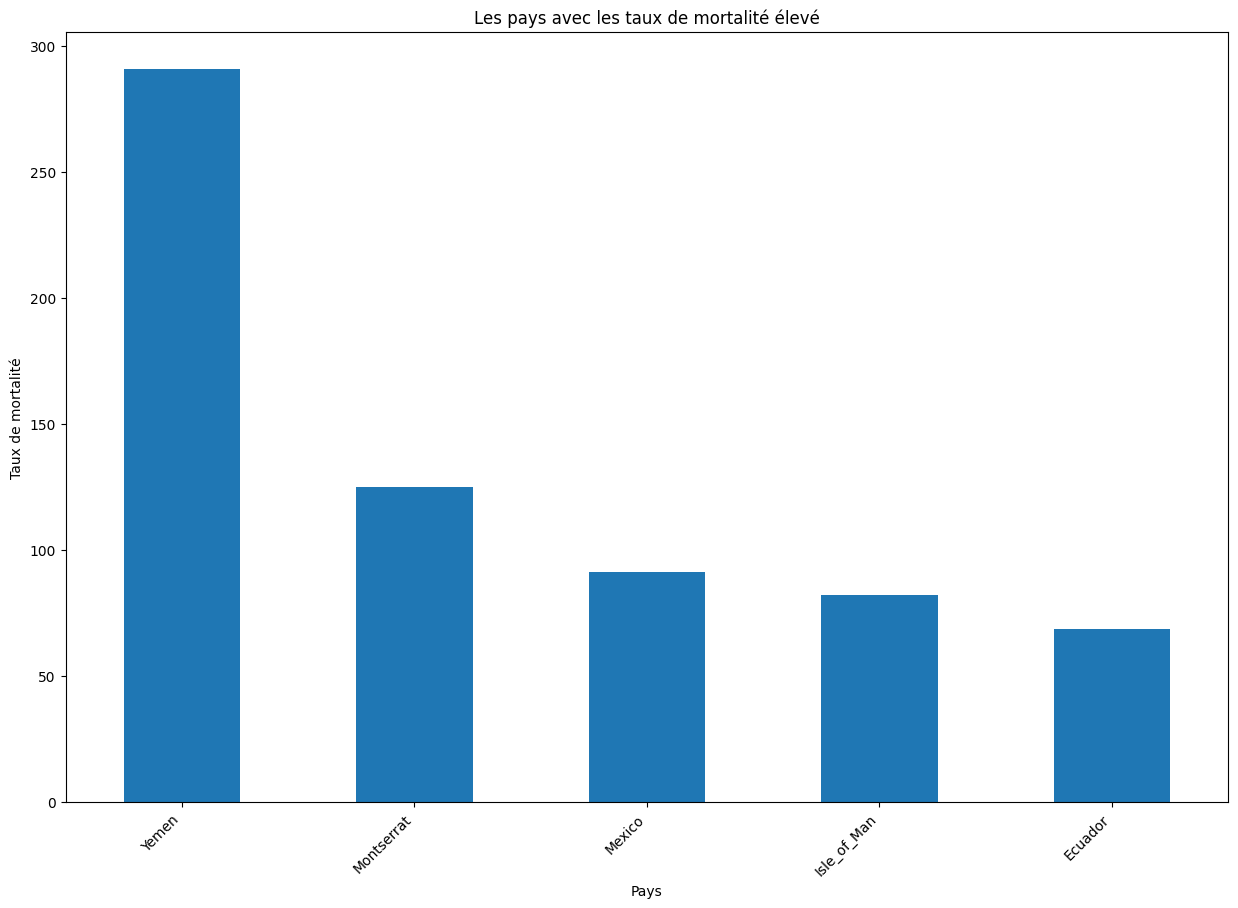

In [39]:
#Graphique
plt.figure(figsize=(15,10))
ax = df_by_country['mortality_rate'].sort_values(ascending=False).head(5).plot.bar()
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('Pays')
ax.set_ylabel('Taux de mortalité')
ax.set_title('Les pays avec les taux de mortalité élevé')


#Pays avec le plus de morts


/tmp/ipykernel_1328/1412130679.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


Text(0.5, 1.0, 'Les pays avec le plus de morts')

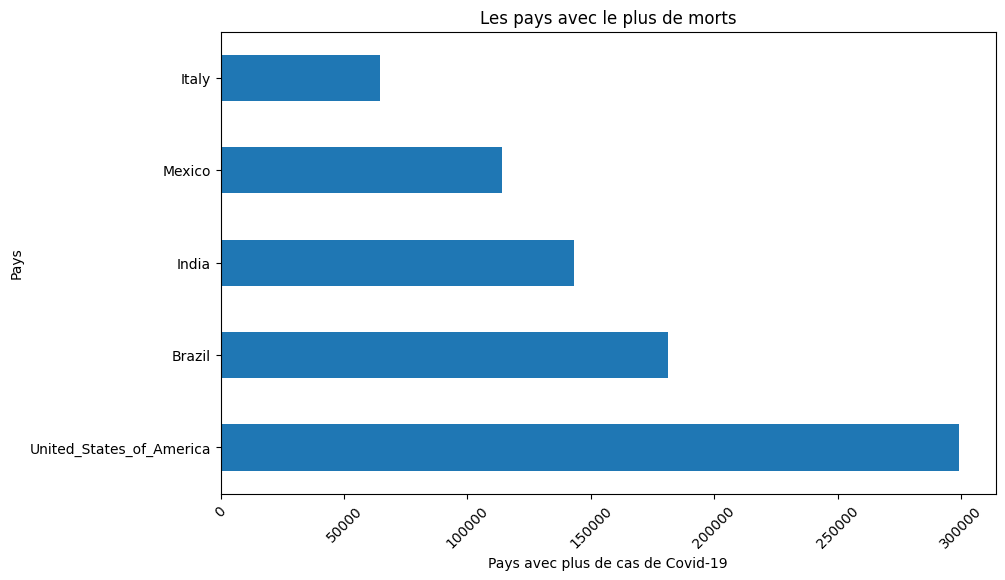

In [46]:
plt.figure(figsize=(10,6))
ax = df_by_country['deaths'].sort_values(ascending=False).head(5).plot.barh()
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_xlabel('Pays avec plus de cas de Covid-19')
ax.set_ylabel('Pays')
ax.set_title('Les pays avec le plus de morts')

#Effet du confinement sur le nombre de cas

In [50]:
df_by_month = df.groupby('month')[['cases', 'deaths']].sum()
df_by_month

,cases,deaths
month,,
1,9767,212
2,74717,2702
3,714475,35668
4,2338739,189142
5,2891247,140118
6,4249352,134069
7,7065668,166185
8,7958523,178556
9,8452473,162120


Text(0, 0.5, 'Nombre de mort')

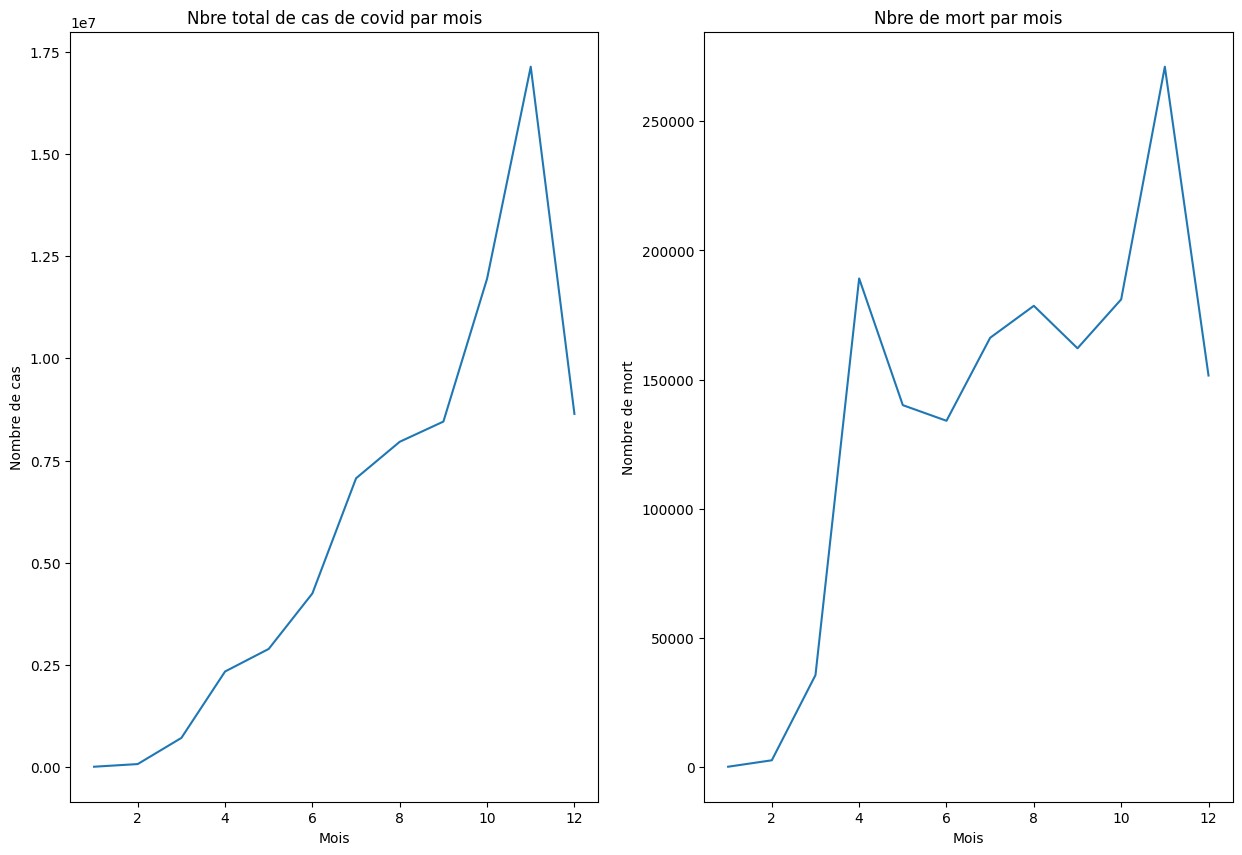

In [54]:
fig=plt.figure(figsize=(15,10))
ax1=fig.add_subplot(1,2,1)
ax2=fig.add_subplot(1,2,2)

df_by_month['cases'].plot(kind='line', ax=ax1)
ax1.set_title('Nbre total de cas de covid par mois')
ax1.set_xlabel('Mois')
ax1.set_ylabel('Nombre de cas')
df_by_month['deaths'].plot(kind='line', ax=ax2)
ax2.set_title('Nbre de mort par mois')
ax2.set_xlabel('Mois')
ax2.set_ylabel('Nombre de mort')


Le nombre cas n'a pas baissé malgré le confinement
Mais le nombre de mort a baissé puis repris sa croissance

In [58]:
df_germany =df[df.countriesAndTerritories =="Germany"]
df_germany_montwise = df_germany.groupby('month')[['cases', 'deaths']].sum()
df_germany_grouped = df_germany_montwise.reset_index()


df_france =df[df.countriesAndTerritories =="France"]
df_france_montwise = df_france.groupby('month')[['cases', 'deaths']].sum()
df_france_grouped = df_france_montwise.reset_index()


df_italy =df[df.countriesAndTerritories =="Italy"]
df_italy_montwise = df_italy.groupby('month')[['cases', 'deaths']].sum()
df_italy_grouped = df_italy_montwise.reset_index()


df_uk =df[df.countriesAndTerritories =="United_Kingdom"]
df_uk_montwise = df_uk.groupby('month')[['cases', 'deaths']].sum()
df_uk_grouped = df_uk_montwise.reset_index()

Text(0.5, 1.0, 'Evolution France')

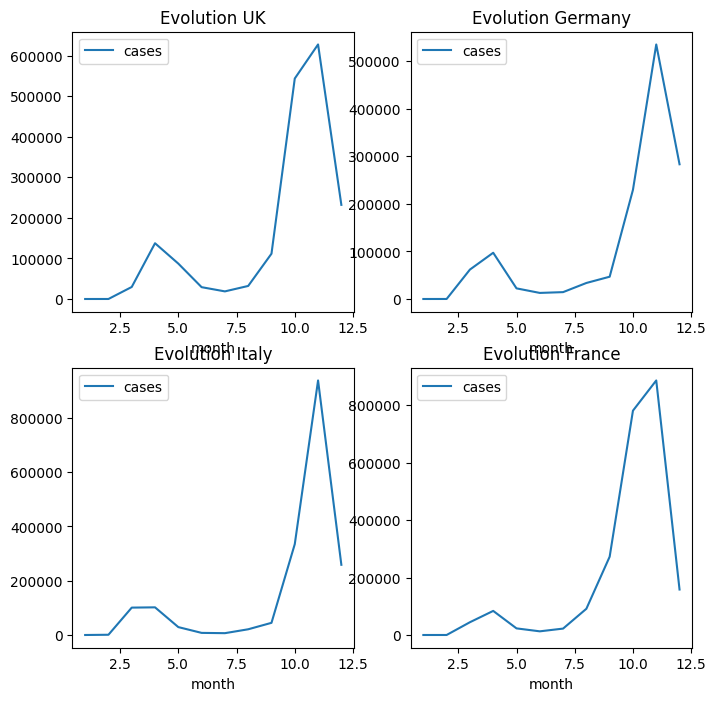

In [61]:
fig=plt.figure(figsize=(8,8))
ax1=fig.add_subplot(2,2,1)
df_uk_grouped.plot(kind='line', x='month', y='cases', ax=ax1)
ax1.set_title('Evolution UK')

ax2=fig.add_subplot(2,2,2)
df_germany_grouped.plot(kind='line', x='month', y='cases', ax=ax2)
ax2.set_title('Evolution Germany')

ax3=fig.add_subplot(2,2,3)
df_italy_grouped.plot(kind='line', x='month', y='cases', ax=ax3)
ax3.set_title('Evolution Italy')

ax4=fig.add_subplot(2,2,4)
df_france_grouped.plot(kind='line', x='month', y='cases', ax=ax4)
ax4.set_title('Evolution France')
